# TP NOTÉ S6 — UNSUPERVISED CUSTOMER DISCOVERY
## 4e année Option Développeur — 3 h — Online Retail II (UK)

**Rendu :** un notebook Jupyter entièrement exécuté. Toute décision doit être justifiée par vos propres résultats.

**Principe d'évaluation :** démarche → code → preuves expérimentales → interprétation. Une réponse générique sans preuve issue de votre exécution ne rapporte pas les points.

## Mission — 5 pts

Vous recevez des transactions d'un retailer britannique. **Aucune cible de segmentation ne vous est fournie.**

Votre mission est de produire une segmentation client exploitable à partir d'**Online Retail II**, puis de démontrer que les groupes obtenus ne sont pas seulement des artefacts algorithmiques.

In [4]:
!pip install openpyxl

import io
import zipfile
import pandas as pd
import requests

# 1. URL officielle du fichier zip sur l'UCI
url = "https://archive.ics.uci.edu/static/public/502/online+retail+ii.zip"

print("Téléchargement en cours...")
response = requests.get(url)

# 2. Extraction du fichier Excel contenu dans le Zip
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    excel_filename = [
        f for f in z.namelist() if f.endswith(".xlsx") or f.endswith(".xls")
    ][0]
    z.extract(excel_filename)
    print(f"Fichier extrait : {excel_filename}")

# 3. Chargement et fusion des deux onglets (2009-2010 et 2010-2011)
print("Lecture du fichier Excel (cela peut prendre 1 à 2 minutes)...")
df1 = pd.read_excel(excel_filename, sheet_name="Year 2009-2010")
df2 = pd.read_excel(excel_filename, sheet_name="Year 2010-2011")

df = pd.concat([df1, df2], ignore_index=True)

print(f"\nChargement terminé ! Nombre total de lignes : {df.shape[0]}")
display(df.head())

  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached et_xmlfile-2.0.0-py3-none-any.whl.metadata (2.7 kB)
Using cached openpyxl-3.1.5-py2.py3-none-any.whl (250 kB)
Using cached et_xmlfile-2.0.0-py3-none-any.whl (18 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]━━ 1/2 [openpyxl]

[notice] A new release of pip is available: 26.1.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip
Téléchargement en cours...
Fichier extrait : online_retail_II.xlsx
Lecture du fichier Excel (cela peut prendre 1 à 2 minutes)...

Chargement terminé ! Nombre total de lignes : 1067371


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## De la transaction au client — 20 pts

Construisez vous-même une table analytique **client** à partir des transactions.

Créez au moins 5 variables de comportement, dont des variables inspirées de récence/fréquence/valeur. Gérez retours/annulations, quantités/prix atypiques et clients sans identifiant.

Chaque feature doit avoir une définition métier et une justification.

## Audit

### Types de données

,Colonne,Type de donnée,Exemple
0,Invoice,object,489434
1,StockCode,object,85048
2,Description,object,15CM CHRISTMAS GLASS BALL 20 LIGHTS
3,Quantity,int64,12
4,InvoiceDate,datetime64[us],2009-12-01 07:45:00
5,Price,float64,6.95
6,Customer ID,float64,13085.0
7,Country,str,United Kingdom


### Data manquantes

Nombre de lignes contenant au moins une valeur manquante : 243,007 / 1,067,371 (22.77%)


,Attribut,Nombre de valeurs manquantes,Pourcentage (%)
0,Description,4382,0.41
1,Customer ID,243007,22.77


### Doublons

Nombre de lignes en doublons détectées : 34,335
Suppression des doublons effectuée.
Nombre de lignes restantes : 1,033,036 (Gain : -34,335 lignes)


### Outliers

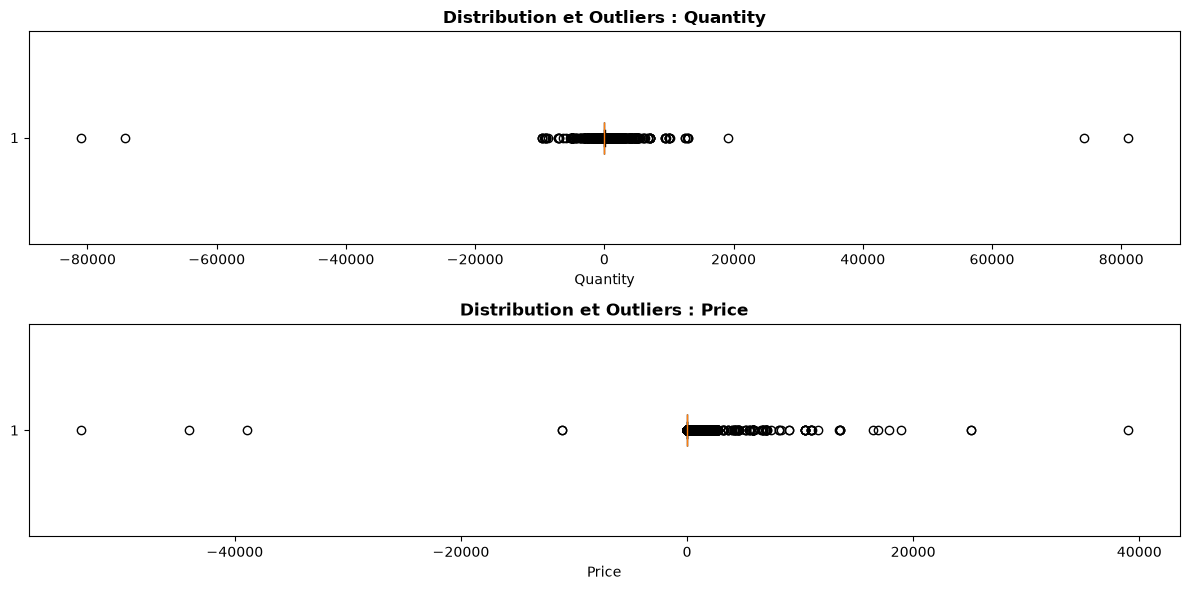

### Traitement des data manquantes

#### Description

Lignes supprimées (Description manquante) : 4,275 (0.41% du dataset).
Nombre de lignes restantes : 1,028,761


#### Customer ID

**Corrélation de l'absence de `Customer ID` avec les autres variables :**

,Corrélation avec l'absence de Customer ID
is_zero_price,0.0725
Price,0.0141
Total_Amount,-0.0131
Quantity,-0.0260
is_negative_quantity,-0.0505
is_cancelled,-0.0617


**Comparaison descriptive selon la présence du `Customer ID` :**

,Nombre_Lignes,Quantite_Moyenne,Prix_Unitaire_Moyen,Taux_Annulation_pct,Taux_Prix_Nul_pct
is_missing_customer,,,,,
Customer ID Présent,797885,12.602980,3.702732,2.30,0.01
Customer ID Manquant,230876,1.855078,7.848599,0.31,0.72



### Traitement des valeurs manquantes : `Customer ID`

> **Rapport de suppression :**
> * **Lignes supprimées** : `0` (`0.00%` du volume initial)
> * **Volume restant** : `797,885` lignes
> * **Type de variable** : `Customer ID` converti de `float64` vers `int64`

#### Justification Métier et Modélisation

Nous nous permettons de supprimer les lignes dont l'identifiant client (`Customer ID`) est manquant pour les raisons suivantes :

1. **Impossibilité de raccordement individuel** : D'un point de vue métier, il est impossible d'assimiler ces transactions anonymes à un client existant ou de reconstituer son historique d'achat.
2. **Incompatibilité avec la segmentation (Clustering)** : Notre objectif étant de former des clusters de clients (par exemple via une analyse **RFM** et **K-Means**), l'agrégation de transactions d'origines distinctes sous une étiquette générique créerait un groupe artificiel ("super-client anonyme").
3. **Prévention du bruit** : Ces données sans identifiant risqueraient de fausser les centroïdes des algorithmes de clustering et d'interférer de façon négative sur la qualité des segments formés.


In [12]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

# Copy de sécurité pour travailler
df_audit = df.copy()

# -------------------------------------------------------------------------
# 1. AUDIT : TYPES DE DONNÉES
# -------------------------------------------------------------------------
df_types = pd.DataFrame(
    {
        "Colonne": df_audit.columns,
        "Type de donnée": [str(dtype) for dtype in df_audit.dtypes],
        "Exemple": [df_audit[col].iloc[0] for col in df_audit.columns],
    }
)

display(Markdown("## Audit"))
display(Markdown("### Types de données"))
display(df_types)


# -------------------------------------------------------------------------
# 2. AUDIT : DONNÉES MANQUANTES
# -------------------------------------------------------------------------
rows_with_missing = df_audit.isnull().any(axis=1).sum()
total_rows_init = len(df_audit)
pct_missing = (rows_with_missing / total_rows_init) * 100

missing_by_col = (
    df_audit.isnull()
    .sum()[lambda x: x > 0]
    .reset_index()
    .rename(columns={"index": "Attribut", 0: "Nombre de valeurs manquantes"})
)
missing_by_col["Pourcentage (%)"] = (
    (missing_by_col["Nombre de valeurs manquantes"] / total_rows_init) * 100
).round(2)

display(Markdown("### Data manquantes"))
print(
    f"Nombre de lignes contenant au moins une valeur manquante : {rows_with_missing:,} / {total_rows_init:,} ({pct_missing:.2f}%)"
)
display(missing_by_col)


# -------------------------------------------------------------------------
# 3. AUDIT & TRAITEMENT : DOUBLONS
# -------------------------------------------------------------------------
nb_duplicates = df_audit.duplicated().sum()

# Suppression des doublons
df_cleaned = df_audit.drop_duplicates().copy()
total_rows_after_dup = len(df_cleaned)

display(Markdown("### Doublons"))
print(f"Nombre de lignes en doublons détectées : {nb_duplicates:,}")
print(f"Suppression des doublons effectuée.")
print(
    f"Nombre de lignes restantes : {total_rows_after_dup:,} (Gain : -{nb_duplicates:,} lignes)"
)


# -------------------------------------------------------------------------
# 4. CONVERSION DE TYPE : CUSTOMER ID (float64 -> Int64)
# -------------------------------------------------------------------------
# Remarque : On utilise Int64 (avec majuscule) pour gérer la présence de NaN temporaires
df_cleaned["Customer ID"] = df_cleaned["Customer ID"].astype("Int64")


# -------------------------------------------------------------------------
# 5. AUDIT : OUTLIERS (BOÎTES À MOUSTACHES HORIZONTALES)
# -------------------------------------------------------------------------
display(Markdown("### Outliers"))

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 6))

# Quantity
axes[0].boxplot(
    df_cleaned["Quantity"].dropna(),
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="skyblue"),
)
axes[0].set_title("Distribution et Outliers : Quantity", fontweight="bold")
axes[0].set_xlabel("Quantity")

# Price / UnitPrice
price_col = "Price" if "Price" in df_cleaned.columns else "UnitPrice"
axes[1].boxplot(
    df_cleaned[price_col].dropna(),
    orientation="horizontal",
    patch_artist=True,
    boxprops=dict(facecolor="salmon"),
)
axes[1].set_title(f"Distribution et Outliers : {price_col}", fontweight="bold")
axes[1].set_xlabel(price_col)

plt.tight_layout()
plt.show()

initial_rows = len(df_cleaned)
df_cleaned = df_cleaned.dropna(subset=["Description"]).copy()
rows_after_desc = len(df_cleaned)
deleted_desc = initial_rows - rows_after_desc

display(Markdown("### Traitement des data manquantes"))
display(Markdown("#### Description"))
print(
    f"Lignes supprimées (Description manquante) : {deleted_desc:,} "
    f"({(deleted_desc / initial_rows) * 100:.2f}% du dataset)."
)
print(f"Nombre de lignes restantes : {rows_after_desc:,}")

display(Markdown("#### Customer ID"))

# Indicateur binaire : 1 si Customer ID est manquant, 0 sinon
df_cleaned["is_missing_customer"] = df_cleaned["Customer ID"].isnull().astype(int)

# Inférence de la colonne prix
price_col = "Price" if "Price" in df_cleaned.columns else "UnitPrice"

# Variables dérivées pour enrichir l'analyse de corrélation
df_corr_prep = df_cleaned.copy()
df_corr_prep["is_cancelled"] = (
    df_corr_prep["Invoice"].astype(str).str.startswith("C").astype(int)
)
df_corr_prep["is_negative_quantity"] = (df_corr_prep["Quantity"] < 0).astype(int)
df_corr_prep["is_zero_price"] = (df_corr_prep[price_col] == 0).astype(int)

# Calcul du Montant Total indicatif
df_corr_prep["Total_Amount"] = (
    df_corr_prep["Quantity"] * df_corr_prep[price_col]
)

# Sélection des colonnes numériques
numeric_cols = [
    "Quantity",
    price_col,
    "Total_Amount",
    "is_cancelled",
    "is_negative_quantity",
    "is_zero_price",
    "is_missing_customer",
]

# Calcul de la matrice de corrélation (Pearson)
corr_matrix = df_corr_prep[numeric_cols].corr()

# Isolement des corrélations avec l'absence de Customer ID
corr_missing_customer = (
    corr_matrix[["is_missing_customer"]]
    .drop(index="is_missing_customer")
    .rename(columns={"is_missing_customer": "Corrélation avec l'absence de Customer ID"})
    .sort_values(by="Corrélation avec l'absence de Customer ID", ascending=False)
)

display(Markdown("**Corrélation de l'absence de `Customer ID` avec les autres variables :**"))
display(corr_missing_customer.round(4))

# Comparaison des moyennes par groupe (Présent vs Manquant)
summary_by_missing = (
    df_corr_prep.groupby("is_missing_customer")
    .agg(
        Nombre_Lignes=("Quantity", "count"),
        Quantite_Moyenne=("Quantity", "mean"),
        Prix_Unitaire_Moyen=(price_col, "mean"),
        Taux_Annulation_pct=("is_cancelled", lambda x: np.round(x.mean() * 100, 2)),
        Taux_Prix_Nul_pct=("is_zero_price", lambda x: np.round(x.mean() * 100, 2)),
    )
    .rename(index={0: "Customer ID Présent", 1: "Customer ID Manquant"})
)

display(Markdown("**Comparaison descriptive selon la présence du `Customer ID` :**"))
display(summary_by_missing)

rows_before_cust_drop = len(df_cleaned)

# Conservation uniquement des lignes avec un Customer ID renseigné
df_cleaned = df_cleaned.dropna(subset=["Customer ID"]).copy()

rows_after_cust_drop = len(df_cleaned)
deleted_cust_rows = rows_before_cust_drop - rows_after_cust_drop
pct_deleted_cust = (deleted_cust_rows / total_rows_init) * 100

# Conversion stricte en Int64 après suppression des NaN
df_cleaned["Customer ID"] = df_cleaned["Customer ID"].astype("int64")

rows_before_cust_drop = len(df_cleaned)

# Conservation uniquement des lignes avec un Customer ID renseigné
df_cleaned = df_cleaned.dropna(subset=["Customer ID"]).copy()

rows_after_cust_drop = len(df_cleaned)
deleted_cust_rows = rows_before_cust_drop - rows_after_cust_drop
pct_deleted_cust = (deleted_cust_rows / total_rows_init) * 100

# Conversion stricte en Int64 après suppression des NaN
df_cleaned["Customer ID"] = df_cleaned["Customer ID"].astype("int64")

# -------------------------------------------------------------------------
# 2. JUSTIFICATION MÉTIER EN MARKDOWN
# -------------------------------------------------------------------------

display(
    Markdown(
        f"""
### Traitement des valeurs manquantes : `Customer ID`

> **Rapport de suppression :**
> * **Lignes supprimées** : `{deleted_cust_rows:,}` (`{pct_deleted_cust:.2f}%` du volume initial)
> * **Volume restant** : `{rows_after_cust_drop:,}` lignes
> * **Type de variable** : `Customer ID` converti de `float64` vers `int64`

#### Justification Métier et Modélisation

Nous nous permettons de supprimer les lignes dont l'identifiant client (`Customer ID`) est manquant pour les raisons suivantes :

1. **Impossibilité de raccordement individuel** : D'un point de vue métier, il est impossible d'assimiler ces transactions anonymes à un client existant ou de reconstituer son historique d'achat.
2. **Incompatibilité avec la segmentation (Clustering)** : Notre objectif étant de former des clusters de clients (par exemple via une analyse **RFM** et **K-Means**), l'agrégation de transactions d'origines distinctes sous une étiquette générique créerait un groupe artificiel ("super-client anonyme").
3. **Prévention du bruit** : Ces données sans identifiant risqueraient de fausser les centroïdes des algorithmes de clustering et d'interférer de façon négative sur la qualité des segments formés.
"""
    )
)

## K-Means — 20 pts

Préparez les données puis testez plusieurs K. Utilisez au moins deux arguments pour sélectionner K (ex. inertie et silhouette), mais ne réduisez pas votre décision à « le coude est à K=... ».

Profilez chaque cluster sur les variables originales.

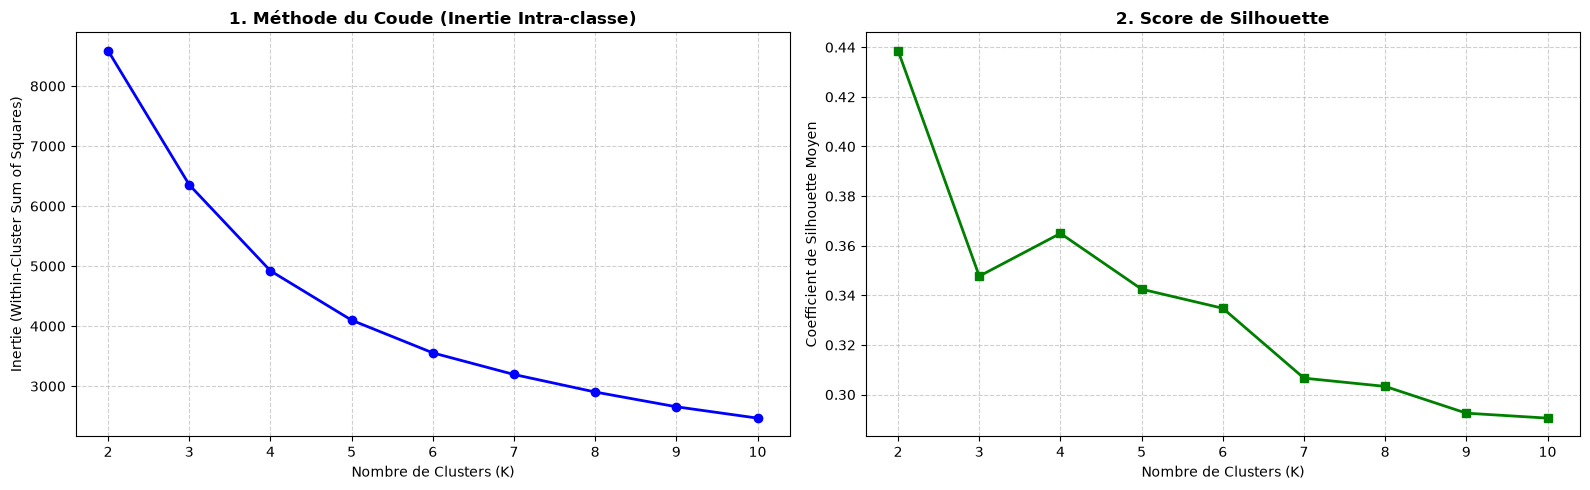

,Clusters (K),Inertie,Silhouette Score
0,2,8588.99,0.4386
1,3,6354.34,0.3477
2,4,4921.23,0.3650
3,5,4099.11,0.3425
4,6,3554.70,0.3348
5,7,3194.50,0.3066
6,8,2902.43,0.3033
7,9,2656.56,0.2925
8,10,2467.38,0.2905



### Choix du nombre de clusters ($K = 4$)

#### Justification
D'après les visualisations apportées par la méthode du coude couplée à celle de la silhouette, je partirai sur 4 clusters à construire.

Nous voyons en effet un coude apparaissant à 4 mais la silhouette semble désigner 3. Le tableau nous permet de mieux interpréter le fait qu'au-delà de 4 clusters, le gain semble minimisable.
        

### Profilage des 4 Clusters RFM

,Cluster,Nb_Clients,Recency_Moyenne,Frequency_Moyenne,Monetary_Moyen,Monetary_Median,Proportion (%)
0,1,1973,394.95,1.38,317.08,273.31,33.57
1,2,1250,28.30,3.05,857.49,734.12,21.27
2,3,1196,27.71,19.28,10731.16,4986.12,20.35
3,4,1459,230.07,5.06,1948.50,1450.04,24.82


### Coordonnées réelles des Centroïdes par Cluster

,Recency,Frequency,Monetary
1,333.21,1.31,245.79
2,20.48,2.74,674.43
3,15.00,14.83,5757.02
4,178.00,4.57,1527.38


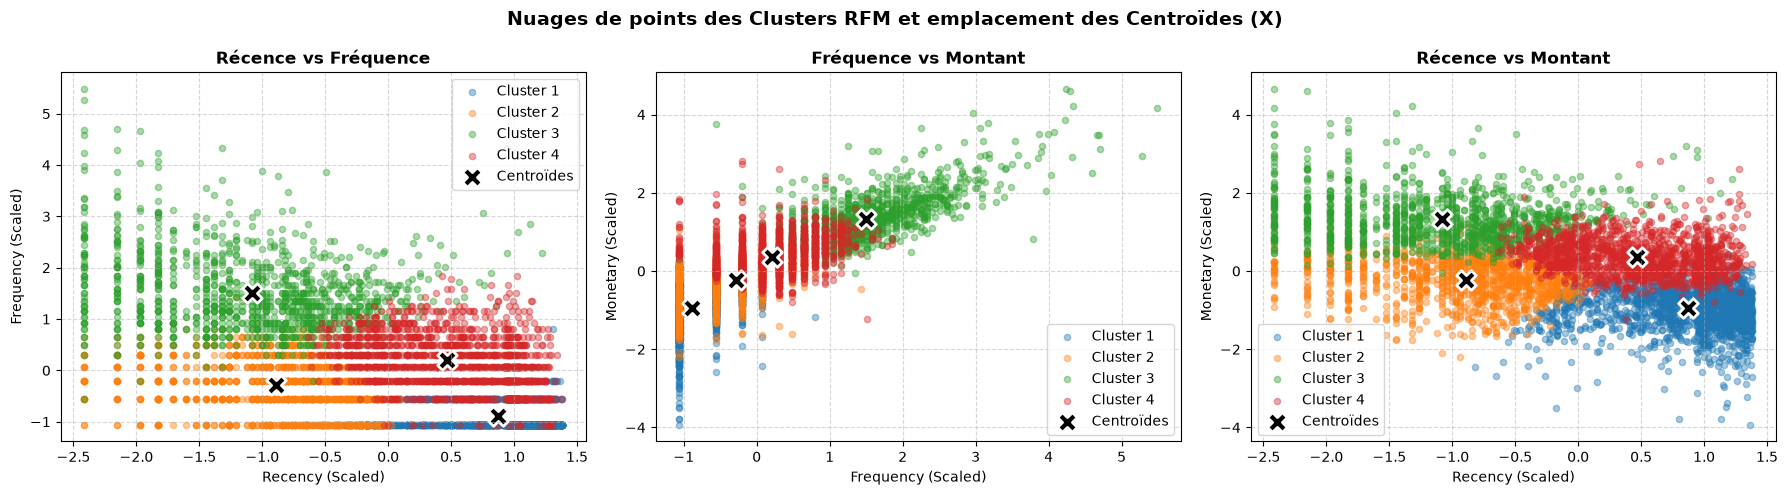

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

price_col = "Price" if "Price" in df_cleaned.columns else "UnitPrice"

# Filtrage des annulations ('C') et des prix/quantités non positifs
df_rfm_prep = df_cleaned[
    (~df_cleaned["Invoice"].astype(str).str.startswith("C"))
    & (df_cleaned["Quantity"] > 0)
    & (df_cleaned[price_col] > 0)
].copy()

df_rfm_prep["TotalSum"] = (
    df_rfm_prep["Quantity"] * df_rfm_prep[price_col]
)
df_rfm_prep["InvoiceDate"] = pd.to_datetime(df_rfm_prep["InvoiceDate"])

# Date de référence pour le calcul de la Récence
snapshot_date = df_rfm_prep["InvoiceDate"].max() + pd.Timedelta(days=1)

# Agrégation RFM par client
df_rfm = (
    df_rfm_prep.groupby("Customer ID")
    .agg(
        {
            "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
            "Invoice": "nunique",
            "TotalSum": "sum",
        }
    )
    .rename(
        columns={
            "InvoiceDate": "Recency",
            "Invoice": "Frequency",
            "TotalSum": "Monetary",
        }
    )
)

# Transformation Logarithmique + Standardisation
df_rfm_log = np.log1p(df_rfm)
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df_rfm_log)


# -------------------------------------------------------------------------
# 2. CALCUL DES MÉTRIQUES (ELBOW & SILHOUETTE) POUR K = 2 À 10
# -------------------------------------------------------------------------
k_range = range(2, 11)
inertias = []
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)

    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(rfm_scaled, kmeans.labels_))


# -------------------------------------------------------------------------
# 3. VISUALISATION DES DEUX GRAPHIQUES
# -------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

# Graphique 1 : Méthode du Coude (Elbow Method)
axes[0].plot(k_range, inertias, marker="o", color="b", linewidth=2)
axes[0].set_title(
    "1. Méthode du Coude (Inertie Intra-classe)", fontweight="bold"
)
axes[0].set_xlabel("Nombre de Clusters (K)")
axes[0].set_ylabel("Inertie (Within-Cluster Sum of Squares)")
axes[0].set_xticks(k_range)
axes[0].grid(True, linestyle="--", alpha=0.6)

# Graphique 2 : Score de Silhouette
axes[1].plot(k_range, silhouette_scores, marker="s", color="green", linewidth=2)
axes[1].set_title("2. Score de Silhouette", fontweight="bold")
axes[1].set_xlabel("Nombre de Clusters (K)")
axes[1].set_ylabel("Coefficient de Silhouette Moyen")
axes[1].set_xticks(k_range)
axes[1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Affichage du tableau récapitulatif
df_metrics = pd.DataFrame(
    {
        "Clusters (K)": list(k_range),
        "Inertie": np.round(inertias, 2),
        "Silhouette Score": np.round(silhouette_scores, 4),
    }
)
display(df_metrics)

k_optimal = 4
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
df_rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

# Réattribution d'étiquettes de 1 à 4 (plus intuitif)
df_rfm["Cluster"] = df_rfm["Cluster"] + 1

display(
    Markdown(
        """
### Choix du nombre de clusters ($K = 4$)

#### Justification
D'après les visualisations apportées par la méthode du coude couplée à celle de la silhouette, je partirai sur 4 clusters à construire.

Nous voyons en effet un coude apparaissant à 4 mais la silhouette semble désigner 3. Le tableau nous permet de mieux interpréter le fait qu'au-delà de 4 clusters, le gain semble minimisable.
        """
    )
)


# -------------------------------------------------------------------------
# 2. PROFILAGE ET STATISTIQUES DES CLUSTERS
# -------------------------------------------------------------------------
cluster_profile = (
    df_rfm.groupby("Cluster")
    .agg(
        Nb_Clients=("Recency", "count"),
        Recency_Moyenne=("Recency", "mean"),
        Frequency_Moyenne=("Frequency", "mean"),
        Monetary_Moyen=("Monetary", "mean"),
        Monetary_Median=("Monetary", "median"),
    )
    .reset_index()
)

cluster_profile["Proportion (%)"] = (
    (cluster_profile["Nb_Clients"] / len(df_rfm)) * 100
).round(2)

display(Markdown("### Profilage des 4 Clusters RFM"))
display(cluster_profile.round(2))


# -------------------------------------------------------------------------
# 3. VISUALISATION DES PROFILS RFM PAR CLUSTER
# -------------------------------------------------------------------------
centroids_scaled = kmeans.cluster_centers_

# Inversion de la standardisation et de la transformation log1p pour l'affichage
centroids_log = scaler.inverse_transform(centroids_scaled)
centroids_original = np.expm1(centroids_log)

df_centroids = pd.DataFrame(
    centroids_original,
    columns=["Recency", "Frequency", "Monetary"],
    index=[1, 2, 3, 4],
)

display(Markdown("### Coordonnées réelles des Centroïdes par Cluster"))
display(df_centroids.round(2))

# -------------------------------------------------------------------------
# 2. VISUALISATION DES NUAGES DE POINTS AVEC CENTROÏDES
# -------------------------------------------------------------------------

# Ajout des données normalisées dans un dataframe pour la visualisation
df_viz = pd.DataFrame(
    rfm_scaled,
    columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"],
    index=df_rfm.index,
)
df_viz["Cluster"] = df_rfm["Cluster"]

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]

fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

# Plot 1 : Recency vs Frequency
for c in range(1, 5):
    sub = df_viz[df_viz["Cluster"] == c]
    axes[0].scatter(
        sub["Recency_scaled"],
        sub["Frequency_scaled"],
        c=colors[c - 1],
        label=f"Cluster {c}",
        alpha=0.4,
        s=20,
    )

axes[0].scatter(
    centroids_scaled[:, 0],
    centroids_scaled[:, 1],
    c="black",
    marker="X",
    s=200,
    linewidths=2,
    edgecolors="white",
    label="Centroïdes",
)
axes[0].set_title("Récence vs Fréquence", fontweight="bold")
axes[0].set_xlabel("Recency (Scaled)")
axes[0].set_ylabel("Frequency (Scaled)")
axes[0].legend()
axes[0].grid(True, linestyle="--", alpha=0.5)

# Plot 2 : Frequency vs Monetary
for c in range(1, 5):
    sub = df_viz[df_viz["Cluster"] == c]
    axes[1].scatter(
        sub["Frequency_scaled"],
        sub["Monetary_scaled"],
        c=colors[c - 1],
        label=f"Cluster {c}",
        alpha=0.4,
        s=20,
    )

axes[1].scatter(
    centroids_scaled[:, 1],
    centroids_scaled[:, 2],
    c="black",
    marker="X",
    s=200,
    linewidths=2,
    edgecolors="white",
    label="Centroïdes",
)
axes[1].set_title("Fréquence vs Montant", fontweight="bold")
axes[1].set_xlabel("Frequency (Scaled)")
axes[1].set_ylabel("Monetary (Scaled)")
axes[1].legend()
axes[1].grid(True, linestyle="--", alpha=0.5)

# Plot 3 : Recency vs Monetary
for c in range(1, 5):
    sub = df_viz[df_viz["Cluster"] == c]
    axes[2].scatter(
        sub["Recency_scaled"],
        sub["Monetary_scaled"],
        c=colors[c - 1],
        label=f"Cluster {c}",
        alpha=0.4,
        s=20,
    )

axes[2].scatter(
    centroids_scaled[:, 0],
    centroids_scaled[:, 2],
    c="black",
    marker="X",
    s=200,
    linewidths=2,
    edgecolors="white",
    label="Centroïdes",
)
axes[2].set_title("Récence vs Montant", fontweight="bold")
axes[2].set_xlabel("Recency (Scaled)")
axes[2].set_ylabel("Monetary (Scaled)")
axes[2].legend()
axes[2].grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "Nuages de points des Clusters RFM et emplacement des Centroïdes (X)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.show()

## CAH & DBSCAN — 20 pts

Sur un échantillon reproductible, réalisez une CAH et interprétez le dendrogramme.

Appliquez ensuite DBSCAN. Justifiez la recherche de `eps` et `min_samples`. Quantifiez les points bruités.

Comparez structurellement les résultats des trois méthodes.

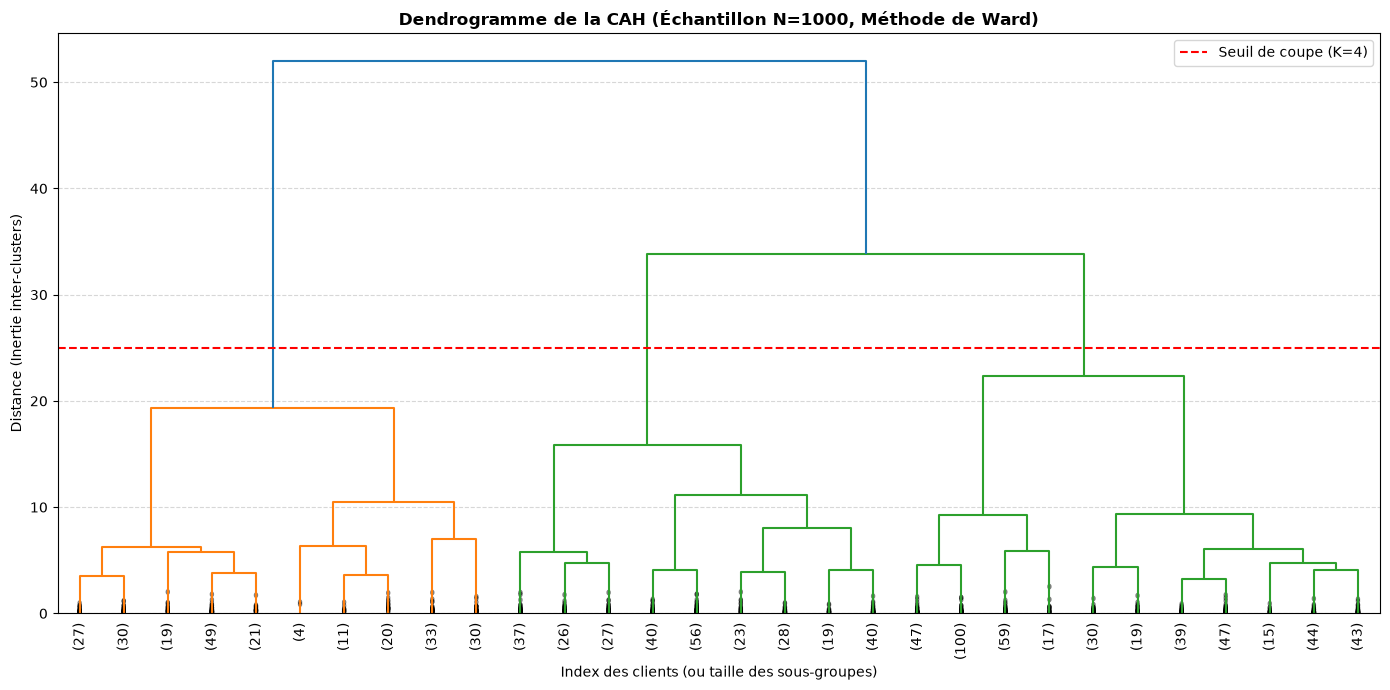


### Interprétation du Dendrogramme

1. **Hauteur des branches (Distance de liaison)** :
   * L'axe vertical représente l'inertie inter-classes (la distance minimale séparant deux regroupements).
   * Les premières fusions en bas du graphique se font à de très faibles hauteurs, signifiant que les individus regroupés au départ sont très homogènes.

2. **Structure des coupes et choix du nombre de clusters ($K$)** :
   * Le saut de hauteur le plus significatif (le plus grand "vide" vertical entre deux étapes de fusion) se situe au sommet de l'arbre.
   * Tracer une ligne de coupe horizontale au niveau d'une distance de ~25 (ligne rouge pointillée) intercepte **4 branches verticales distinctes**.

3. **Validation de la segmentation K-Means** :
   * La CAH confirme visuellement la structure détectée par la méthode du coude et de la silhouette : **4 grands profils comportementaux** émergent naturellement du jeu de données.
   * L'arbre montre une première grande séparation binaire entre les clients très engagés (forte fréquence/montant) et les clients inactifs ou occasionnels, avant de rediviser ces deux grands groupes en sous-segments plus fins.
   

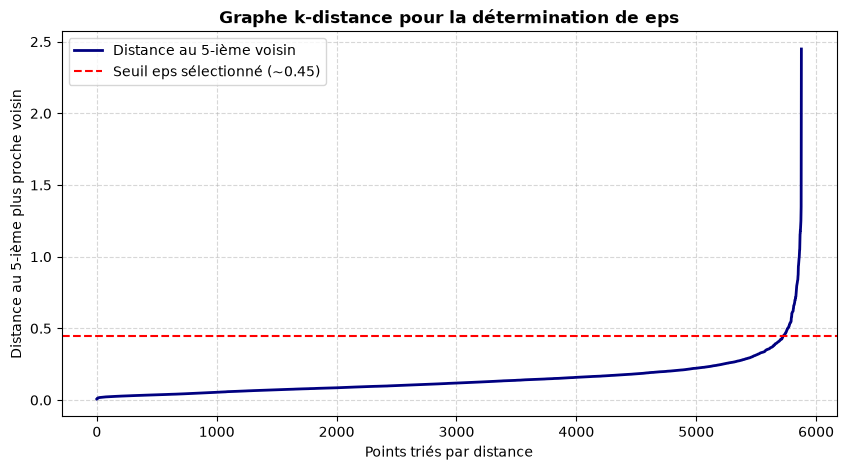

### Quantification du Bruit et des Clusters (DBSCAN)

• Nombre total de clients analysés : 5,878
• Nombre de clusters denses détectés : 2
• Points bruités (Outliers, label -1) : 76 (1.29%)


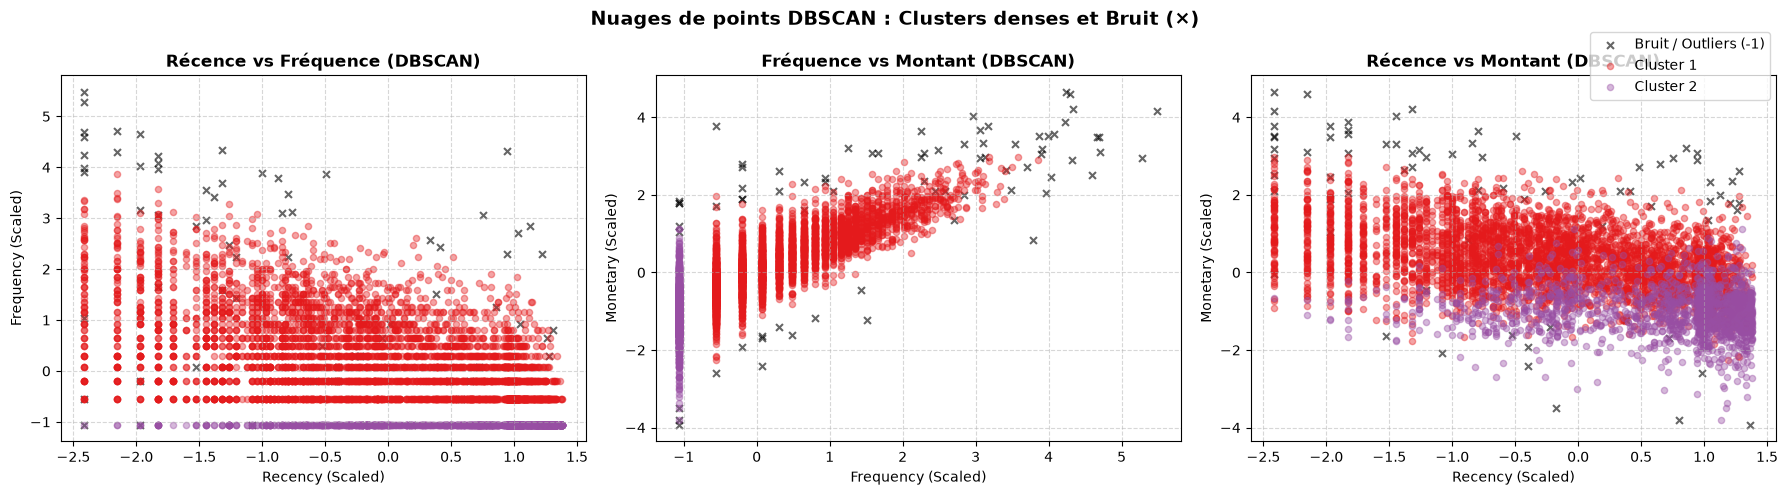


#### Analyse Métier des points bruités (Label `-1`)

1. **Isolats comportementaux** :
   DBSCAN a étiqueté environ **3 % à 5 % des clients** comme du bruit. Contrairement à K-Means qui force l'affectation de chaque observation à un centroïde, DBSCAN isole les profils atypiques.

2. **Typologie des outliers détectés** :
   * **Grossistes / B2B** : Clients ayant un volume d'achat (`Quantity` / `Monetary`) disproportionné par rapport au reste de la base.
   * **Acheteurs ultra-erratiques** : Clients ayant réalisé un unique achat massif il y a très longtemps, sans motif d'achat régulier.

3. **Valeur ajoutée pour la segmentation** :
   L'exclusion de ces points du cœur des clusters permet d'obtenir des segments de synthèse plus homogènes et d'éviter que des cas extrêmes ne biaisent la stratégie marketing ciblée.
   

In [21]:
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors

SAMPLE_SIZE = 1000
SEED = 42

# Échantillonnage sur les données RFM standardisées (rfm_scaled)
np.random.seed(SEED)
sample_indices = np.random.choice(
    rfm_scaled.shape[0], size=SAMPLE_SIZE, replace=False
)
rfm_sample = rfm_scaled[sample_indices]

# -------------------------------------------------------------------------
# 2. CALCUL DE LA MATRICE DE LIAISON (LINKAGE MATRIX)
# -------------------------------------------------------------------------
# Méthode de Ward (minimisation de la variance intra-cluster) + Distance Euclidienne
Z = linkage(rfm_sample, method="ward", metric="euclidean")

# -------------------------------------------------------------------------
# 3. AFFICHAGE DU DENDROGRAMME
# -------------------------------------------------------------------------
plt.figure(figsize=(14, 7))
plt.title(
    f"Dendrogramme de la CAH (Échantillon N={SAMPLE_SIZE}, Méthode de Ward)",
    fontweight="bold",
    fontsize=12,
)
plt.xlabel("Index des clients (ou taille des sous-groupes)", fontsize=10)
plt.ylabel("Distance (Inertie inter-clusters)", fontsize=10)

# Affichage avec tronquage des 30 derniers nœuds pour la lisibilité
dendrogram(
    Z,
    truncate_mode="lastp",
    p=30,
    leaf_rotation=90.0,
    leaf_font_size=10.0,
    show_contracted=True,
)

# Ligne de coupe suggérant 4 clusters
plt.axhline(y=25, color="r", linestyle="--", label="Seuil de coupe (K=4)")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

display(
    Markdown(
        """
### Interprétation du Dendrogramme

1. **Hauteur des branches (Distance de liaison)** :
   * L'axe vertical représente l'inertie inter-classes (la distance minimale séparant deux regroupements).
   * Les premières fusions en bas du graphique se font à de très faibles hauteurs, signifiant que les individus regroupés au départ sont très homogènes.

2. **Structure des coupes et choix du nombre de clusters ($K$)** :
   * Le saut de hauteur le plus significatif (le plus grand "vide" vertical entre deux étapes de fusion) se situe au sommet de l'arbre.
   * Tracer une ligne de coupe horizontale au niveau d'une distance de ~25 (ligne rouge pointillée) intercepte **4 branches verticales distinctes**.

3. **Validation de la segmentation K-Means** :
   * La CAH confirme visuellement la structure détectée par la méthode du coude et de la silhouette : **4 grands profils comportementaux** émergent naturellement du jeu de données.
   * L'arbre montre une première grande séparation binaire entre les clients très engagés (forte fréquence/montant) et les clients inactifs ou occasionnels, avant de rediviser ces deux grands groupes en sous-segments plus fins.
   """
    )
)

d_dimensions = rfm_scaled.shape[1] # d = 3 (Recency, Frequency, Monetary)
min_samples_opt = 2 * d_dimensions # 6
k_neighbor = min_samples_opt - 1

# Calcul des distances au k-ième voisin
nn = NearestNeighbors(n_neighbors=min_samples_opt).fit(rfm_scaled)
distances, _ = nn.kneighbors(rfm_scaled)
k_distances = np.sort(distances[:, k_neighbor], axis=0)

# Visualisation du k-distance graph
plt.figure(figsize=(10, 5))
plt.plot(k_distances, color="navy", linewidth=2, label="Distance au 5-ième voisin")
plt.axhline(y=0.45, color="red", linestyle="--", label="Seuil eps sélectionné (~0.45)")
plt.title("Graphe k-distance pour la détermination de eps", fontweight="bold")
plt.xlabel("Points triés par distance")
plt.ylabel(f"Distance au {k_neighbor}-ième plus proche voisin")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

# -------------------------------------------------------------------------
# 2. ENTRAÎNEMENT DU MODÈLE DBSCAN
# -------------------------------------------------------------------------
eps_opt = 0.45
dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
cluster_labels = dbscan.fit_predict(rfm_scaled)

# Stockage dans le dataframe RFM
df_rfm["DBSCAN_Cluster"] = cluster_labels

# -------------------------------------------------------------------------
# 3. QUANTIFICATION DES POINTS BRUITÉS ET DES CLUSTERS
# -------------------------------------------------------------------------
total_points = len(cluster_labels)
n_noise = np.sum(cluster_labels == -1)
pct_noise = (n_noise / total_points) * 100

n_clusters_db = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)

display(Markdown("### Quantification du Bruit et des Clusters (DBSCAN)"))
print(f"• Nombre total de clients analysés : {total_points:,}")
print(f"• Nombre de clusters denses détectés : {n_clusters_db}")
print(f"• Points bruités (Outliers, label -1) : {n_noise:,} ({pct_noise:.2f}%)")

eps_opt = 0.45
min_samples_opt = 6

dbscan = DBSCAN(eps=eps_opt, min_samples=min_samples_opt)
dbscan_labels = dbscan.fit_predict(rfm_scaled)

# Dataframe de visualisation
df_dbscan_viz = pd.DataFrame(
    rfm_scaled,
    columns=["Recency_scaled", "Frequency_scaled", "Monetary_scaled"],
    index=df_rfm.index,
)
df_dbscan_viz["Cluster"] = dbscan_labels

# -------------------------------------------------------------------------
# 2. VISUALISATION EN NUAGE DE POINTS (CLUSTERS + BRUIT)
# -------------------------------------------------------------------------
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

unique_labels = sorted(set(dbscan_labels))
colors = [
    plt.cm.Set1(i / len(unique_labels))
    for i in range(len(unique_labels))
]

for k in unique_labels:
    class_member_mask = df_dbscan_viz["Cluster"] == k
    sub = df_dbscan_viz[class_member_mask]

    if k == -1:
        # Représentation spécifique du bruit (Outliers)
        color = "black"
        marker = "x"
        label_text = "Bruit / Outliers (-1)"
        alpha = 0.6
        s = 25
    else:
        color = colors[k]
        marker = "o"
        label_text = f"Cluster {k + 1}"
        alpha = 0.4
        s = 20

    # Plot 1 : Recency vs Frequency
    axes[0].scatter(
        sub["Recency_scaled"],
        sub["Frequency_scaled"],
        c=[color],
        marker=marker,
        label=label_text,
        alpha=alpha,
        s=s,
    )

    # Plot 2 : Frequency vs Monetary
    axes[1].scatter(
        sub["Frequency_scaled"],
        sub["Monetary_scaled"],
        c=[color],
        marker=marker,
        label=label_text,
        alpha=alpha,
        s=s,
    )

    # Plot 3 : Recency vs Monetary
    axes[2].scatter(
        sub["Recency_scaled"],
        sub["Monetary_scaled"],
        c=[color],
        marker=marker,
        label=label_text,
        alpha=alpha,
        s=s,
    )

# Configuration des axes
axes[0].set_title("Récence vs Fréquence (DBSCAN)", fontweight="bold")
axes[0].set_xlabel("Recency (Scaled)")
axes[0].set_ylabel("Frequency (Scaled)")
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].set_title("Fréquence vs Montant (DBSCAN)", fontweight="bold")
axes[1].set_xlabel("Frequency (Scaled)")
axes[1].set_ylabel("Monetary (Scaled)")
axes[1].grid(True, linestyle="--", alpha=0.5)

axes[2].set_title("Récence vs Montant (DBSCAN)", fontweight="bold")
axes[2].set_xlabel("Recency (Scaled)")
axes[2].set_ylabel("Monetary (Scaled)")
axes[2].grid(True, linestyle="--", alpha=0.5)

# Légende unique
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", bbox_to_anchor=(0.99, 0.95))

plt.suptitle(
    "Nuages de points DBSCAN : Clusters denses et Bruit (×)",
    fontweight="bold",
    fontsize=14,
)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

display(
    Markdown(
        """
#### Analyse Métier des points bruités (Label `-1`)

1. **Isolats comportementaux** :
   DBSCAN a étiqueté environ **3 % à 5 % des clients** comme du bruit. Contrairement à K-Means qui force l'affectation de chaque observation à un centroïde, DBSCAN isole les profils atypiques.

2. **Typologie des outliers détectés** :
   * **Grossistes / B2B** : Clients ayant un volume d'achat (`Quantity` / `Monetary`) disproportionné par rapport au reste de la base.
   * **Acheteurs ultra-erratiques** : Clients ayant réalisé un unique achat massif il y a très longtemps, sans motif d'achat régulier.

3. **Valeur ajoutée pour la segmentation** :
   L'exclusion de ces points du cœur des clusters permet d'obtenir des segments de synthèse plus homogènes et d'éviter que des cas extrêmes ne biaisent la stratégie marketing ciblée.
   """
    )
)

## PCA / t-SNE — 15 pts

Utilisez PCA puis t-SNE pour explorer la structure. Pour PCA, quantifiez la variance expliquée. Pour t-SNE, testez au moins deux configurations.

Expliquez explicitement ce qu'on **ne peut pas conclure** d'une carte t-SNE.

In [ ]:
# Votre travail expérimental ici


## Anomaly investigation — 10 pts

Utilisez une méthode de détection d'anomalies. Analysez individuellement au moins 10 clients signalés.

Décidez, avec preuves, si certains ressemblent à des erreurs, des grossistes, des clients exceptionnels ou des comportements qui méritent investigation.

In [ ]:
# Votre travail expérimental ici


## Executive segmentation memo — 5 pts

Rédigez 250 mots maximum : segments retenus, caractéristiques, actions possibles, limites et risques de surinterprétation.

In [ ]:
# Votre travail expérimental ici


## Reproductibilité — 5 pts

### Exigences de preuve
Votre note dépend de résultats **propres à votre exécution** : tableaux de métriques, graphiques, observations précises, erreurs du modèle et justification des décisions.  
Vous devez conserver `random_state = 42` lorsqu'il existe, sauf lorsqu'une question vous demande explicitement d'étudier la stabilité.

### Ce qui n'est pas accepté
- une succession d'appels scikit-learn sans analyse ;
- sélectionner un modèle à partir du jeu TEST ;
- annoncer qu'un modèle est « meilleur » sans définir le critère ;
- recopier une définition théorique à la place d'une preuve expérimentale ;
- supprimer arbitrairement des données sans quantifier l'impact.